# Catalog covariance diagonals: simulation vs analytic

This notebook builds a publication-quality comparison plot for the catalog case:
- ratio of diagonal covariance entries, $\mathrm{Cov}_{\rm sim}/\mathrm{Cov}_{\rm analytic}$
- overlaid jackknife $1\sigma$ uncertainty band

It follows the same plotting style used in your Pk notebook (serif, inward ticks, clean palette).

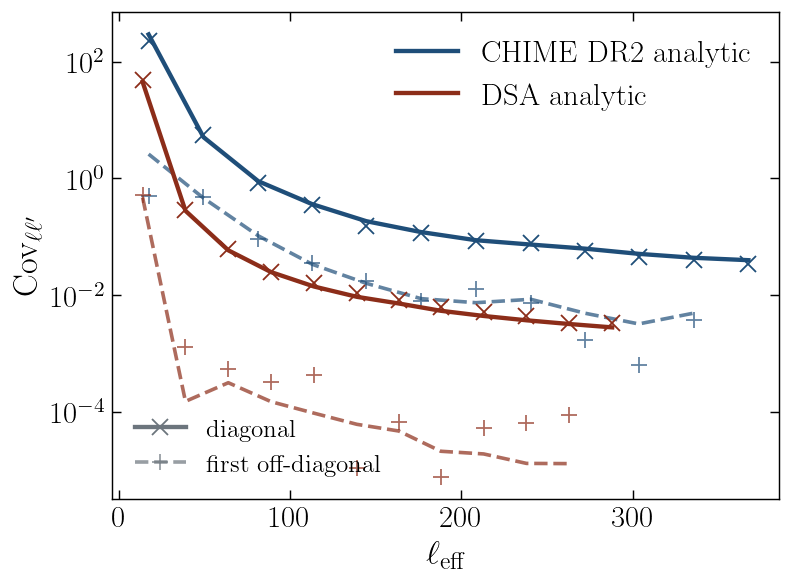

In [1]:
from pathlib import Path
import shutil

import numpy as np
import matplotlib.pyplot as plt

# ---- plotting style (matching your standard notebook style) -----------------
_fs, _fs2 = 17, 20
if shutil.which("latex") is not None:
    plt.rc("text", usetex=True)
    plt.rcParams["font.serif"] = ["Computer Modern"]

plt.rc("font", family="serif")
plt.rcParams.update({
    "font.size": _fs,
    "axes.titlesize": _fs2,
    "axes.labelsize": _fs2 - 1,
    "xtick.labelsize": _fs,
    "ytick.labelsize": _fs,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": False,
    "legend.frameon": False,
    "figure.dpi": 130,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.top": True,
    "ytick.right": True,
})

C_BLUE = "#1f4e79"
C_ORANGE = "#8c2d19"
C_GREEN = "#2d6a4f"
C_GRAY = "#6c757d"


# ---- data loading helpers ---------------------------------------------------
def pick_existing(paths):
    for p in paths:
        if p.exists():
            return p
    raise FileNotFoundError("None of the candidate files exist:\n" + "\n".join(str(p) for p in paths))


def locate_in_candidates(filenames, directories):
    candidates = [d / fn for d in directories for fn in filenames]
    return pick_existing(candidates)


def get_first_available(data, keys):
    for k in keys:
        if k in data.files:
            return data[k]
    return None


def jackknife_cov_error(pcl_dm, n_blocks=100):
    pcl_dm = np.asarray(pcl_dm)
    n_real = pcl_dm.shape[0]

    # Keep blocks valid even for small ensembles.
    n_blocks = min(n_blocks, max(2, n_real // 4))
    block_size = n_real // n_blocks
    if block_size < 1:
        raise ValueError("Not enough realizations for jackknife block estimate")

    cov_full = np.cov(pcl_dm.T)
    cov_jk = np.zeros((n_blocks, cov_full.shape[0], cov_full.shape[1]))

    for k in range(n_blocks):
        mask = np.ones(n_real, dtype=bool)
        i0 = k * block_size
        i1 = (k + 1) * block_size if k < n_blocks - 1 else n_real
        mask[i0:i1] = False
        cov_jk[k] = np.cov(pcl_dm[mask].T)

    cov_jk_mean = cov_jk.mean(axis=0)
    cov_err = np.sqrt((n_blocks - 1) / n_blocks * np.sum((cov_jk - cov_jk_mean) ** 2, axis=0))
    return cov_err


# ---- datasets: (analytic file, simulation file, label) ----------------------
cwd = Path.cwd().resolve()
dirs_to_try = [cwd, cwd / "plots", cwd.parent, cwd.parent / "plots"]

datasets = [
    ("covariance_catalog_analytic.npz",  "mock_catalog.npz",      "CHIME catalog"),
    ("covariance_forecast_analytic.npz", "mock_masked_fixed.npz", "Forecast (masked)"),
]

fig, axes = plt.subplots()

label_sim = ["CHIME DR2", "DSA"]
label_ana = ["CHIME DR2 analytic", "DSA analytic"]
colors = [C_BLUE, C_ORANGE]

plots_dir = None
for (ana_name, sim_name, label) in datasets:
    ax = axes
    ana_path = locate_in_candidates([ana_name], dirs_to_try)
    sim_path = locate_in_candidates([sim_name], dirs_to_try)
    plots_dir = ana_path.parent
    ana = np.load(ana_path)
    sim = np.load(sim_path)

    cov_analytic = get_first_available(ana, ["cov_theory", "cov_analytic", "cov_gpu_th", "cov"])
    ell_eff = get_first_available(sim, ["pcl_ell_eff", "ell_eff"])
    if ell_eff is None:
        ell_eff = get_first_available(ana, ["ell_eff", "pcl_ell_eff"])

    if "pcl_dm" in sim.files:
        pcl_dm = sim["pcl_dm"]
        cov_sim = np.cov(pcl_dm.T)
    else:
        cov_sim = get_first_available(sim, ["cov_sim", "cov", "covariance"])
        pcl_dm = None

    cov_err = get_first_available(ana, ["cov_err", "covariance_err"])
    if cov_err is None and pcl_dm is not None:
        cov_err = jackknife_cov_error(pcl_dm, n_blocks=100)

    n = min(cov_sim.shape[0], cov_analytic.shape[0], len(ell_eff))
    ell_eff = np.asarray(ell_eff)[:n]
    diag_sim = np.diag(cov_sim)[:n]
    diag_ana = np.diag(cov_analytic)[:n]
    diag_cov_err = np.diag(cov_err)[:n] if cov_err is not None else np.zeros(n)

    ci = datasets.index((ana_name, sim_name, label))
    # main diagonal
    ax.semilogy(ell_eff, diag_sim, color=colors[ci], lw=2.4, ls="", marker="x", ms=9)
    ax.semilogy(ell_eff, diag_ana, color=colors[ci], lw=2.4, ls="-",
                label=label_ana[ci])
    # first off-diagonal |Cov_{l,l+1}| (abs: it can be negative on a log axis)
    offdiag_sim = np.abs(np.diag(cov_sim, 1))[:n - 1]
    offdiag_ana = np.abs(np.diag(cov_analytic, 1))[:n - 1]
    ax.semilogy(ell_eff[:n - 1], offdiag_sim, color=colors[ci], lw=2.0, ls="",
                marker="+", ms=9, alpha=0.7)
    ax.semilogy(ell_eff[:n - 1], offdiag_ana, color=colors[ci], lw=2.0, ls="--", alpha=0.7)
    ax.set_xlabel(r"$\ell_{\rm eff}$")
    ax.set_ylabel(r"$\mathrm{Cov}_{\ell\ell'}$")

from matplotlib.lines import Line2D
leg1 = ax.legend(loc="upper right", fontsize=_fs)          # datasets (colour)
ax.add_artist(leg1)
_style = [Line2D([0], [0], color=C_GRAY, ls="-", lw=2.4, marker="x", ms=9),
          Line2D([0], [0], color=C_GRAY, ls="--", lw=2.0, marker="+", ms=9, alpha=0.7)]
ax.legend(_style, ["diagonal", "first off-diagonal"], loc="lower left", fontsize=_fs - 3)

fig.tight_layout()
out_pdf = (plots_dir or cwd) / "covariance_catalog_diagonals.pdf"
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()


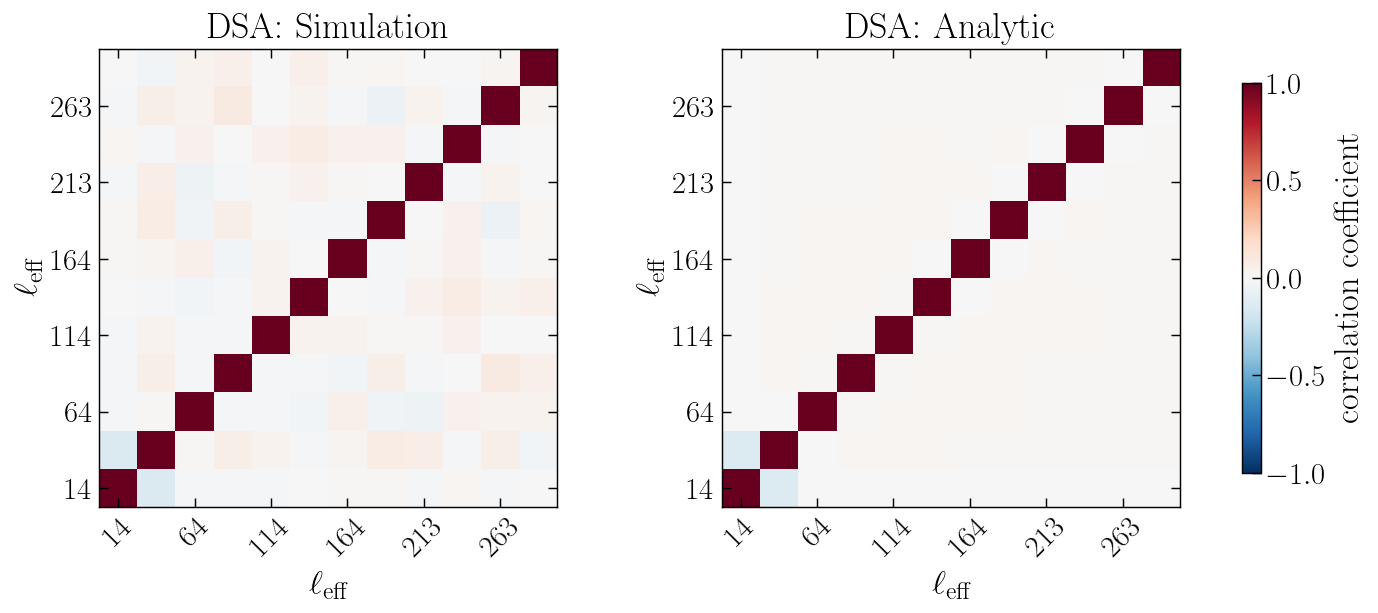

Saved: /Users/robert/Documents/Git/cpcl_gpu/plots/covariance_DSA_corrcoef.pdf


In [2]:
# ---- correlation-coefficient matrices for the DSA case ----------------------
ana_path = locate_in_candidates(["covariance_forecast_analytic.npz"], dirs_to_try)
sim_path = locate_in_candidates(["mock_masked_fixed.npz"], dirs_to_try)
plots_dir = ana_path.parent
ana = np.load(ana_path)
sim = np.load(sim_path)

cov_ana = get_first_available(ana, ["cov_theory", "cov_analytic", "cov_gpu_th", "cov"])
cov_sim = np.cov(sim["pcl_dm"].T)
ell = get_first_available(sim, ["pcl_ell_eff", "ell_eff"])

n = min(cov_ana.shape[0], cov_sim.shape[0], len(ell))
cov_ana, cov_sim, ell = cov_ana[:n, :n], cov_sim[:n, :n], np.asarray(ell)[:n]


def corrcoef(C):
    d = np.sqrt(np.diag(C))
    return C / np.outer(d, d)


corr_sim = corrcoef(cov_sim)
corr_ana = corrcoef(cov_ana)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
for ax, R, ttl in zip(axs, [corr_sim, corr_ana], ["Simulation", "Analytic"]):
    im = ax.imshow(R, origin="lower", cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title(f"DSA: {ttl}")
    t = np.arange(n)[::2]
    ax.set_xticks(t)
    ax.set_yticks(t)
    ax.set_xticklabels([f"{ell[i]:.0f}" for i in t], rotation=45)
    ax.set_yticklabels([f"{ell[i]:.0f}" for i in t])
    ax.set_xlabel(r"$\ell_{\rm eff}$")
    ax.set_ylabel(r"$\ell_{\rm eff}$")
cbar = fig.colorbar(im, ax=axs, shrink=0.85)
cbar.set_label("correlation coefficient")

out_pdf = plots_dir / "covariance_DSA_corrcoef.pdf"
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()
print(f"Saved: {out_pdf}")


In [3]:
# ---- load the signal prediction (theory bandpowers at ell_eff) --------------
sim_path = locate_in_candidates(["mock_masked_fixed.npz"], dirs_to_try)
sim = np.load(sim_path)

ell_eff   = get_first_available(sim, ["pcl_ell_eff", "ell_eff"])
signal_bp = get_first_available(sim, ["pcl_theory"])   # decoupled theory C_ell at ell_eff

print("ell_eff   :", ell_eff)
print("signal_bp :", signal_bp)


ell_eff   : [ 14.   39.   64.   89.  114.  139.  163.5 188.  213.  238.  263.  288. ]
signal_bp : [42.12508842  7.84744062  3.93767914  2.42461755  1.66845294  1.22625686
  0.94982492  0.76069301  0.62045215  0.51702993  0.43701761  0.37541175]


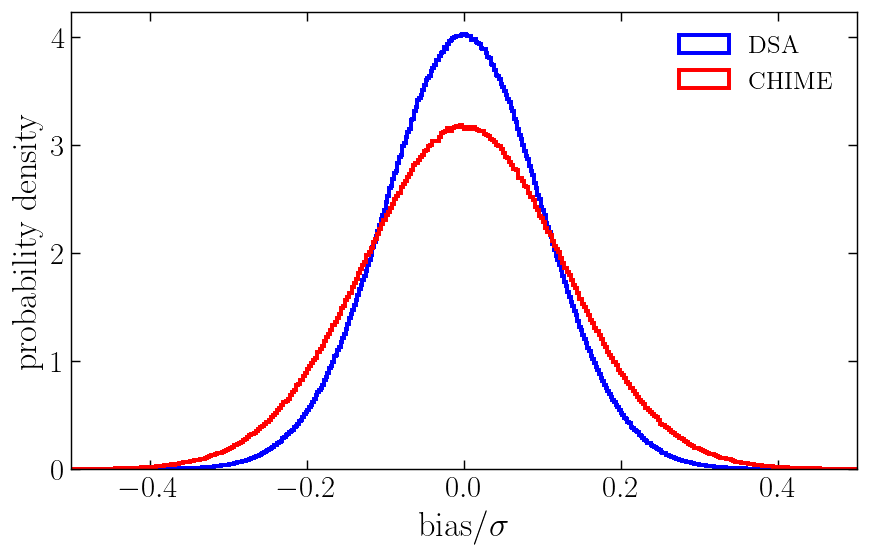

Saved: /Users/robert/Documents/Git/cpcl_gpu/plots/amplitude_fit_bias_DSA_CHIME.pdf


In [28]:
# ---- amplitude A^2 fit: difference between sim- and analytic-covariance ------
# Data model d = A^2 * signal_bp + noise, mocks drawn from the SIMULATED cov.
# For each realisation we recover A^2 with both covariances and histogram the
# per-realisation difference (A2_sim - A2_ana)/sigma_ana.  Iterated over both
# footprints (DSA and CHIME).
from numpy.random import default_rng

fit_sets = [
    ("covariance_forecast_analytic.npz", "mock_masked_fixed.npz", "DSA",   "blue"),
    ("covariance_catalog_analytic.npz",  "mock_catalog.npz",      "CHIME", "red"),
]

A2_true = 1.0
Nreal = 10_000_000
fig, ax = plt.subplots(figsize=(7, 4.6))
for ana_name, sim_name, label, color in fit_sets:
    ana = np.load(locate_in_candidates([ana_name], dirs_to_try))
    sim = np.load(locate_in_candidates([sim_name], dirs_to_try))
    cov_ana = get_first_available(ana, ["cov_theory", "cov_analytic", "cov_gpu_th", "cov"])
    pcl_dm  = sim["pcl_dm"]
    cov_sim = np.cov(pcl_dm.T)
    t = np.asarray(get_first_available(sim, ["pcl_theory"]), float)   # template (A^2 = 1)
    m = min(len(t), cov_sim.shape[0], cov_ana.shape[0])
    t, cov_sim, cov_ana = t[:m], cov_sim[:m, :m], cov_ana[:m, :m]

    # Inverse covariances (sample inverse Hartlap-debiased).
    n_mocks = pcl_dm.shape[0]
    hartlap = (n_mocks - m - 2) / (n_mocks - 1)
    Cinv_sim = hartlap * np.linalg.inv(cov_sim)
    Cinv_ana = np.linalg.inv(cov_ana)

    # Many realisations drawn from the simulated covariance.
    rng = default_rng(0)
    L = np.linalg.cholesky(cov_sim)
    d = A2_true * t[None, :] + rng.standard_normal((Nreal, m)) @ L.T
    A2_sim = (d @ Cinv_sim @ t) / (t @ Cinv_sim @ t)
    A2_ana = (d @ Cinv_ana @ t) / (t @ Cinv_ana @ t)

    bias = (A2_sim - A2_ana) / A2_ana.std()
    ax.hist(bias, bins=500, lw=2.2, color=color, density=True, histtype="step", alpha=1,
            label=fr"{label} ")
    
ax.set_xlabel(r"$\mathrm{bias}/\sigma$")
ax.set_ylabel("probability density")
ax.set_xlim(-0.5, 0.5)
ax.legend(loc="best", fontsize=_fs - 3)
fig.tight_layout()
out_pdf = plots_dir / "amplitude_fit_bias_DSA_CHIME.pdf"
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()
print(f"Saved: {out_pdf}")


SIM cov:  <chi2>/dof = 0.986   frac(PTE<0.05) = 0.046   KS-vs-uniform p = 2.64e-45
ANA cov:  <chi2>/dof = 1.128   frac(PTE<0.05) = 0.096   KS-vs-uniform p = 0.00e+00


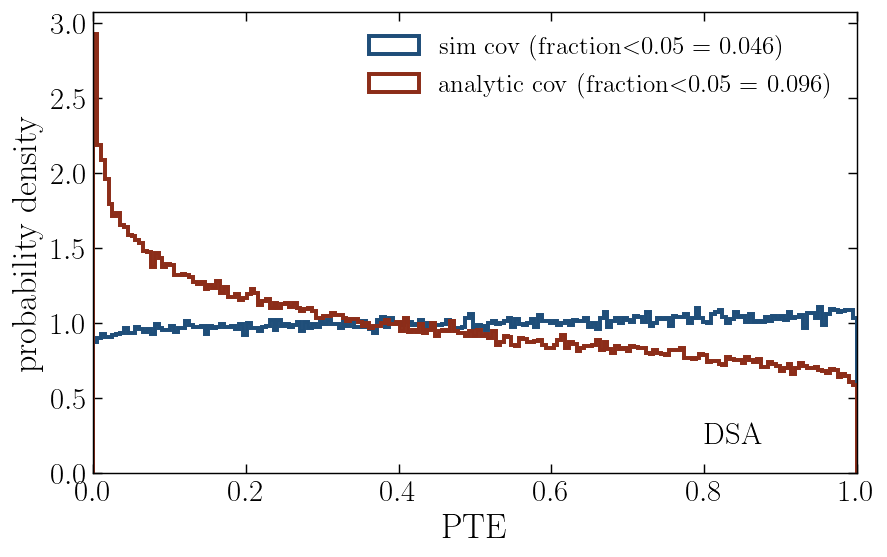

Saved: /Users/robert/Documents/Git/cpcl_gpu/plots/pte_DSA.pdf


In [ ]:
# ---- PTE (goodness-of-fit) test: sim- vs analytic-covariance ----------------
# Mocks are drawn from the SIMULATED covariance, so here cov_sim is the EXACT
# data covariance (no Hartlap): fitting with it gives an exactly-uniform PTE and
# serves as the reference.  Fitting with the analytic covariance instead reveals
# any mismatch as a departure from uniformity.  For each mock we fit A^2, form
# chi^2 = r C^-1 r of the residual (dof = m - 1), and record PTE = P(chi^2 > obs).
from numpy.random import default_rng
from scipy.stats import chi2 as chi2_dist, kstest


ana_path = locate_in_candidates(["covariance_forecast_analytic.npz"], dirs_to_try)
sim_path = locate_in_candidates(["mock_masked_fixed.npz"], dirs_to_try)
sim = np.load(sim_path)
cov_ana = get_first_available(np.load(ana_path), ["cov_theory", "cov_analytic", "cov_gpu_th", "cov"])
pcl_dm  = sim["pcl_dm"]
cov_sim = np.cov(pcl_dm.T)
t = np.asarray(get_first_available(sim, ["pcl_theory"]), float)   # template (A^2 = 1)


m = min(len(t), cov_sim.shape[0], cov_ana.shape[0])
t, cov_sim, cov_ana = t[:m], cov_sim[:m, :m], cov_ana[:m, :m]
hartlap = (n_mocks - m - 2) / (n_mocks - 1)


Cinv_sim_exact = hartlap*np.linalg.inv(cov_sim)      # cov_sim is exact for these mocks
Cinv_ana_exact = np.linalg.inv(cov_ana)
dof = m - 1                                   # one fitted amplitude

rng = default_rng(1)
Npte = 300000
L = np.linalg.cholesky(cov_sim/hartlap)
A2_true = 1.0
d = t[None, :] + rng.standard_normal((Npte, m)) @ L.T


def pte_for(Cinv):
    A2 = (d @ Cinv @ t) / (t @ Cinv @ t)      # MLE amplitude with this covariance
    r = d - A2[:, None] * t[None, :]          # residual
    chisq = np.einsum("ni,ij,nj->n", r, Cinv, r)
    return chisq
        #chi2_dist.sf(chisq, dof), chisq


chi2_sim = pte_for(Cinv_sim_exact*hartlap)
chi2_ana = pte_for(Cinv_ana_exact)
pte_sim = chi2_dist.sf(chi2_sim, dof)
pte_ana = chi2_dist.sf(chi2_ana, dof)

for name, pte, cs in [("SIM", pte_sim, chi2_sim), ("ANA", pte_ana, chi2_ana)]:
    ks = kstest(pte, "uniform")
    print(f"{name} cov:  <chi2>/dof = {cs.mean()/dof:.3f}   "
          f"frac(PTE<0.05) = {(pte < 0.05).mean():.3f}   "
          f"KS-vs-uniform p = {ks.pvalue:.2e}")

fig, ax = plt.subplots(figsize=(7, 4.6))
bins = np.linspace(0, 1, 200)
ax.hist(pte_sim, bins=bins, histtype="step", lw=2.2, color=C_BLUE, density=True,
        label=f"sim cov  (fraction$<$0.05 = {(pte_sim<0.05).mean():.3f})")
ax.hist(pte_ana, bins=bins, histtype="step", lw=2.2, color=C_ORANGE, density=True,
        label=f"analytic cov  (fraction$<$0.05 = {(pte_ana<0.05).mean():.3f})")
ax.set_xlabel("PTE")
ax.set_ylabel("probability density")
plt.text(.8,.2,r"DSA", fontsize=_fs, color="black")
ax.legend(loc="best", fontsize=_fs - 3)
fig.tight_layout()
out_pdf = plots_dir / "pte_DSA.pdf"
plt.xlim(0, 1)
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()
print(f"Saved: {out_pdf}")
